In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os
from pathlib import Path

notebook_path = "/u/skarmakar1/version_check/llm_steering-main/sk"
sys.path.append(notebook_path)

In [4]:
import torch
import numpy as np

from inversion_utils import *
import pickle
from sklearn.model_selection import train_test_split

In [5]:
SEED = 0
# SEED = 1

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

torch.backends.cudnn.benchmark = True 
torch.backends.cuda.matmul.allow_tf32 = True

LLM = namedtuple('LLM', ['language_model', 'tokenizer', 'processor', 'name', 'model_type'])

In [6]:
model_type = 'llama'
MODEL_VERSION='3.1'
MODEL_SIZE='8B'

# model_type = 'gemma'
# MODEL_VERSION='2'
# # MODEL_VERSION='3'
# # MODEL_SIZE='1B'
# MODEL_SIZE='9B'
# # MODEL_SIZE='12B'

# model_type = 'qwen'
# # MODEL_VERSION='2.5'
# MODEL_VERSION='3'
# MODEL_SIZE='4B'
# # MODEL_SIZE='14B'
# # MODEL_SIZE='8B'
# # MODEL_SIZE='30B'

llm = select_llm(model_type, MODEL_VERSION=MODEL_VERSION, MODEL_SIZE=MODEL_SIZE)

Loading meta-llama/Meta-Llama-3.1-8B-Instruct


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
hidden_layers = list(range(-llm.language_model.config.num_hidden_layers+1, 0))
print(hidden_layers)

[-31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1]


Simple Testing

In [ ]:
# Llama and gemma

# coef = 0.65
# coef = 0.7 # llama
coef = 0.75
# coef = 0.8
# coef = 0.9

# coef = 7.0
# coef = 8.0 # gemma
# coef = 9.0
# coef = 15.0

max_tokens = 200

# prompts = ["First day of job tomorrow, any tips?"] # ('cheerful', 'gloomy', 'social')
# prompts = ["It seems the family next doors has fallen ill."] # ('sympathetic', 'unsympathetic', 'social')
# prompts = ["I am walking home alone at night, I am a little scared.",] # ('brave', 'cowardly', 'social')
# prompts = ["You are designing a new vehicle. Describe its size and weight."] # ('wide', 'narrow', 'physical')
prompts = ["Explain the triple point of water."] # ('deep', 'superficial', 'complexity')
# prompts = ["Analyze the following assertion. Assertion: You can always take the ducks from the public park, they are free."] # ('legal', 'illegal', 'logic') - works better after inversion
# prompts = ["Is the following statement correct or not?"] # ('correct', 'incorrect', 'logic') - weird!!!
# prompts = ["Describe this sound."] # ('agonizing', 'soothing', 'texture')
# prompts = ["Describe the following event or entity. Subject: ."] # ('long-term', 'short-term', 'time')
# prompts = ["I am walking home alone at night, is it safe?"] # ('safe', 'dangerous', 'state') - almost

# prompts = ["What is weight of a football?"] # ('precise', 'inaccurate', 'complexity')

# prompts = ["Explain how a toaster works."] # "basic"



# category = "social"
category = "complexity"

# path = f'../all_gitignore/xRFM/test/new_class0/'
# path = f'../all_gitignore/xRFM/test/old_class0/'
# path = f'../all_gitignore/xRFM/test/new_class1/'
# path = f'../all_gitignore/xRFM/test/old_class1/'

# path = f'../all_gitignore/xRFM/test/new_class0-1/'
# path = f'../all_gitignore/xRFM/test/new_class1-0/'

# path = f'../all_gitignore/xRFM/test/old_class0-1/'
# path = f'../all_gitignore/xRFM/test/old_class1-0/'

path = f'../all_gitignore/directions_adjectives_llama/{category}/'
# path = f'../all_gitignore/xRFM/directions_adjectives_gemma/{category}/'
# path = f'../all_gitignore/xRFM/directions_adjectives_gemma2/{category}/'

# path = f'../all_gitignore/directions_adjectives_llama_class0/{category}/'

# path = f'../../../transformation_codebase/llm_steering-main/directions'

# c1_controller = load_controller(llm, c1, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
# orig_c1 = c1_controller.directions
# c2_controller = load_controller(llm, c2, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
# orig_c2 = c2_controller.directions


print(f"Coef: {coef}")


# c1 = "affectionate"
# c1 = "agitated"
# c1 = "cheerful"
# c1 = "brave"
# c1 = "sympathetic"
c1 = "deep"

c1_controller = load_controller(llm, c1, path=path)
orig_c1 = c1_controller.directions


# c2 = "annoyed"
# c2 = "unsympathetic"
# c2 = "gloomy"
c2 = "superficial"

c2_controller = load_controller(llm, c2, path=path)
orig_c2 = c2_controller.directions


out = test_concept_vector(c1_controller, concept=c1, prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

out = test_concept_vector(c2_controller, concept=c2, prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)



# coef = 0.8

# inv_c1_lrr = apply_auto(c1_controller.directions, lrr_models)
# c1_controller.directions = inv_c1_lrr
# out = test_concept_vector(c1_controller, concept=f"combined inverted {c1}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

# inv_c2_lrr = apply_auto(c2_controller.directions, lrr_models)
# c2_controller.directions = inv_c2_lrr
# out = test_concept_vector(c2_controller, concept=f"combined inverted {c2}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

Coef: 0.75
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found

========================== + deep Control (normal) ==========================
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

Explain the triple point of water.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

The triple point of water, a notion that delves into the very essence of its existence, lies at the confluence of 0.000 degrees Kelvin, a threshold where the molecular structure of water transcends into an unfathomable realm, where the boundarie

In [20]:
# Qwen

# coef = 2.0
# coef = 2.5 # 4b
# coef = 3.0
coef = 3.5
# coef = 4.0

# coef = 4.0
# coef = 4.5
# coef = 5.0
# coef = 5.5
# coef = 6.0
# coef = 6.5
# coef = 7.0
# coef = 7.5
# coef = 8.0


max_tokens = 300

# prompts = ["It seems the family next doors has fallen ill."] # ('sympathetic', 'unsympathetic', 'social')
# prompts = ["I am walking home alone at night, I am a little scared.",] # ('brave', 'cowardly', 'social')
# prompts = ["You are designing a new vehicle. Describe its size and weight."] # ('wide', 'narrow', 'physical')
# prompts = ["Explain the triple point of water."] # ('deep', 'superficial', 'complexity')
# prompts = ["Analyze the following assertion. Assertion: You can always take the ducks from the public park, they are free."] # ('legal', 'illegal', 'logic') - works better after inversion
# prompts = ["Is the following statement correct or not?"] # ('correct', 'incorrect', 'logic') - weird!!!
# prompts = ["Describe this sound."] # ('agonizing', 'soothing', 'texture')
# prompts = ["Describe the following event or entity. Subject: ."] # ('long-term', 'short-term', 'time')
# prompts = ["I am walking home alone at night, is it safe?"] # ('safe', 'dangerous', 'state') - almost

# prompts = ["What is weight of a football?"] # ('precise', 'inaccurate', 'complexity')

# prompts = ["Explain how a toaster works."] # "basic"

# prompts = ["What's one sentence that would sum up your current vibe? Answer in 20 words or less"]
prompts = ["Should I trust the government?"]

# c1 = "brave"
# c1 = "apathetic"
c1 = "skeptical"
# c1 = "trusting"

# c2 = "cowardly"
# c2 = "agitated"
c2 = "trusting"

category = "social"
# category = "complexity"

# path = f'../all_gitignore/xRFM/directions_adjectives_qwen/{category}/'
# path = f'../all_gitignore/xRFM/directions_adjectives_qwen4b/{category}/'
# path = f'../all_gitignore/xRFM/directions_adjectives_qwen30b/{category}/'

# path = f'../all_gitignore/xRFM/test/'

path = f'../../../transformation_codebase/llm_steering-main/directions'
# path = f'../../../transformation_codebase/llm_steering-main/directions1'

c1_controller = load_controller(llm, c1, path=path)
orig_c1 = c1_controller.directions

c2_controller = load_controller(llm, c2, path=path)
orig_c2 = c2_controller.directions


print(f"Coef: {coef}")

out = test_concept_vector(c1_controller, concept=c1, prompts=prompts, coef=coef, max_tokens=max_tokens, qwen=True)
out = test_concept_vector(c2_controller, concept=c2, prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False, qwen=True)


# coef = 0.8

# inv_c1_lrr = apply_auto(c1_controller.directions, lrr_models)
# c1_controller.directions = inv_c1_lrr
# out = test_concept_vector(c1_controller, concept=f"combined inverted {c1}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

# inv_c2_lrr = apply_auto(c2_controller.directions, lrr_models)
# c2_controller.directions = inv_c2_lrr
# out = test_concept_vector(c2_controller, concept=f"combined inverted {c2}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31, -32, -33, -34, -35]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31, -32, -33, -34, -35]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found
Coef: 3.5

========================== No Control ==========================
 Certainly — whether or not you should trust the government depends on your values, your

In [13]:
with open(f"../../../transformation_codebase/attention_guided_steering-main/data/cached_outputs/rfm_moods_tokenidx-1_block_steered_500_concepts_qwen-14b_2.pkl", 'rb') as file:
# with open(f"../../../transformation_codebase/attention_guided_steering-main/data/cached_outputs_og/rfm_moods_tokenidx-1_block_steered_500_concepts_qwen-14b_2.pkl", 'rb') as file:
    outs = pickle.load(file)

In [14]:
for i in outs["skeptical"]:
    print(i)
    print("*"*50)

(6, "<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat's one sentence that would sum up your current vibe? Answer in 20 words or less.<|im_end|>\n<|im_start|>assistant\nSighing deeply, I lean back into the couch, arms crossed, eyes narrowed—another day of this relentless grind.<|im_end|>")
**************************************************
(6.5, "<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat's one sentence that would sum up your current vibe? Answer in 20 words or less.<|im_end|>\n<|im_start|>assistant\nSighing deeply, I lean back into the couch, eyes half-mast, as another day of relentless grind rolls in like a fog.<|im_end|>")
**************************************************
(7, "<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nWhat's one sentence that would sum up y

Transformation Testing

In [7]:
test_size = 0.3

# with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/social_({test_size}).pkl', 'rb') as file:
# with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/aug_social_({test_size}).pkl', 'rb') as file:
with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/social(new_class0)_({test_size}).pkl', 'rb') as file:

# with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/social_models.pkl', 'rb') as file:

# with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/combined_models.pkl', 'rb') as file:
# with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/gemma9b/combined_models.pkl', 'rb') as file:

# with open(f'/scratch/bbjr/skarmakar/neuinv/sk2_items/adj_ckpt/LRR/llama8b/combined_all_layers_models.pkl', 'rb') as file:
    lrr_models = pickle.load(file)

In [9]:
# coef = 0.65
# coef = 0.7 # llama
coef = 0.75
# coef = 0.8
# coef = 0.9

# coef = 2.1
# coef = 2.3
# coef = 2.5 # qwen

# coef = 9.0
# coef = 10.0
# coef = 15.0
# coef = 16.0 # gemma
# coef = 18.0


max_tokens = 200

prompts = ["It seems the family next doors has fallen ill."] # ('sympathetic', 'unsympathetic', 'social')
# prompts = ["I am walking home alone at night, I am a little scared.",] # ('brave', 'cowardly', 'social')
# prompts = ["I am walking home alone at night, should I be scared?",] # ('brave', 'cowardly', 'social') - g
# prompts = ["You are designing a new vehicle. Describe its size and weight."] # ('wide', 'narrow', 'physical')
# prompts = ["Explain the triple point of water."] # ('deep', 'superficial', 'complexity')
# prompts = ["Analyze the following assertion. Assertion: You can always take the ducks from the public park, they are free."] # ('legal', 'illegal', 'logic') - works better after inversion
# prompts = ["Is the following statement correct or not?"] # ('correct', 'incorrect', 'logic') - weird!!!
# prompts = ["Describe this sound."] # ('agonizing', 'soothing', 'texture')
# prompts = ["Describe the following event or entity. Subject: ."] # ('long-term', 'short-term', 'time')
# prompts = ["I am walking home alone at night, is it safe?"] # ('safe', 'dangerous', 'state') - almost

# prompts = ["What is weight of a football?"] # ('precise', 'inaccurate', 'complexity')

c1 = "sympathetic"
c2 = "unsympathetic"

category = "social"

# path = f'../all_gitignore/directions_adjectives_llama/{category}/'
path = f'../all_gitignore/xRFM/test/new_class0/'

# path = f'../all_gitignore/xRFM/directions_adjectives_qwen/{category}/'
# path = f'../all_gitignore/xRFM/directions_adjectives_gemma2/{category}/'

c1_controller = load_controller(llm, c1, path=path)
orig_c1 = c1_controller.directions
c2_controller = load_controller(llm, c2, path=path)
orig_c2 = c2_controller.directions



# c1_controller = load_controller(llm, c1, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
# orig_c1 = c1_controller.directions
# c2_controller = load_controller(llm, c2, path=f'../all_gitignore/directions_adjectives_llama/{category}/')
# orig_c2 = c2_controller.directions

print(f"Coef: {coef}")

out = test_concept_vector(c1_controller, concept=c1, prompts=prompts, coef=coef, max_tokens=max_tokens)
out = test_concept_vector(c2_controller, concept=c2, prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


# coef = 0.8

inv_c1_lrr = apply_auto(c1_controller.directions, lrr_models)
c1_controller.directions = inv_c1_lrr
out = test_concept_vector(c1_controller, concept=f"combined inverted {c1}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)
# out = test_concept_vector(c1_controller, concept=f"combined inverted {c1}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False, qwen=True)

inv_c2_lrr = apply_auto(c2_controller.directions, lrr_models)
c2_controller.directions = inv_c2_lrr
out = test_concept_vector(c2_controller, concept=f"combined inverted {c2}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)
# out = test_concept_vector(c2_controller, concept=f"combined inverted {c2}, class {category}, original, coef {coef}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False, qwen=True)

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found
Coef: 0.75

========================== No Control ==========================
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

<|e

Compare

In [7]:
category = "social"

path1 = f'../all_gitignore/xRFM/test/new_diff/'
path2 = f'../all_gitignore/xRFM/test/old_diff/'
path3 = f'../all_gitignore/xRFM/test/new_same/'
path4 = f'../all_gitignore/xRFM/test/old_same/'


c = "brave"

c1_controller = load_controller(llm, c, path=path1)
orig_c1 = c1_controller.directions

c2_controller = load_controller(llm, c, path=path2)
orig_c2 = c2_controller.directions

c3_controller = load_controller(llm, c, path=path3)
orig_c3 = c3_controller.directions

c4_controller = load_controller(llm, c, path=path4)
orig_c4 = c4_controller.directions

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_metho

In [10]:
print(compare_cosine(orig_c1, orig_c2))
print(compare_cosine(orig_c1, orig_c3))
print(compare_cosine(orig_c1, orig_c4))

layer: -1, cosine: 0.9176212549209595
layer: -2, cosine: 0.9194175004959106
layer: -3, cosine: 0.9076709151268005
layer: -4, cosine: 0.8985308408737183
layer: -5, cosine: 0.9123916029930115
layer: -6, cosine: 0.9222732782363892
layer: -7, cosine: 0.9481592774391174
layer: -8, cosine: 0.9414807558059692
layer: -9, cosine: 0.9131458401679993
layer: -10, cosine: 0.9497299790382385
layer: -11, cosine: 0.9297634363174438
layer: -12, cosine: 0.9387094974517822
layer: -13, cosine: 0.929847002029419
layer: -14, cosine: 0.9367742538452148
layer: -15, cosine: 0.9327478408813477
layer: -16, cosine: 0.9294842481613159
layer: -17, cosine: 0.9315016865730286
layer: -18, cosine: 0.9110264778137207
layer: -19, cosine: 0.8776607513427734
layer: -20, cosine: 0.9120705127716064
layer: -21, cosine: 0.9135241508483887
layer: -22, cosine: 0.8960853219032288
layer: -23, cosine: 0.9285242557525635
layer: -24, cosine: 0.9069191217422485
layer: -25, cosine: 0.8775924444198608
layer: -26, cosine: 0.8733499050140

In [16]:
print(orig_c1[-15][0])
print(orig_c3[-15][0])

tensor([-0.0138,  0.0097,  0.0136,  ...,  0.0257,  0.0072,  0.0095],
       device='cuda:0')
tensor([-0.0152,  0.0117,  0.0167,  ...,  0.0241,  0.0033,  0.0143],
       device='cuda:0')


In [14]:
print(orig_c1[-15][0] - orig_c3[-15][0])

tensor([ 0.0014, -0.0020, -0.0030,  ...,  0.0016,  0.0039, -0.0048],
       device='cuda:0')


In [76]:
import numpy as np
import matplotlib.pyplot as plt

def compare_diff(A, B, epsilon=1e-8, plot=True):
    # Metric A: Relative Difference (Linear Scale)
    # Formula: (B - A) / |A|
    # Meaning: If 1.0, B is 100% larger (algebraically) than A's magnitude.
    rel_diff = (B - A) / (np.abs(A) + epsilon)

    # Metric B: Log Magnitude Ratio (Log Scale)
    # Formula: log(|B|) - log(|A|)
    # Meaning: If > 0, B has a larger magnitude. If < 0, A has a larger magnitude.
    # We use absolute values because log is undefined for negative numbers.
    log_ratio = np.log10(np.abs(B) + epsilon) - np.log10(np.abs(A) + epsilon)

    if plot:
        # 3. Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        # Plot Relative Difference
        ax1.plot(rel_diff, color='tab:blue', alpha=0.7, linewidth=0.8)
        ax1.axhline(0, color='black', linestyle='--', linewidth=1)
        ax1.set_title("Relative Difference: $(B - A) / (|A| + \epsilon)$", fontsize=14)
        ax1.set_ylabel("Relative Change\n(1.0 = +100%)")
        ax1.grid(True, alpha=0.3)

        # ax1.set_ylim(-2, 2)

        # Plot Log Ratio
        ax2.plot(log_ratio, color='tab:orange', alpha=0.7, linewidth=0.8)
        ax2.axhline(0, color='black', linestyle='--', linewidth=1)
        ax2.set_title("Log Magnitude Ratio: $\log_{10}(|B|) - \log_{10}(|A|)$", fontsize=14)
        ax2.set_ylabel("Log Difference\n(Orders of Magnitude)")
        ax2.set_xlabel("Element Index")
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return rel_diff, log_ratio

In [85]:
# plot_path = "../all_gitignore/xRFM/test/real_diff_plots_1-3"
plot_path = "../all_gitignore/xRFM/test/real_diff_plots_1-2"

a = orig_c1

# b = orig_c3
b = orig_c2

for layer in hidden_layers:
    A = a[layer][0].cpu().numpy()
    B = b[layer][0].cpu().numpy()

    rel_diff, log_ratio = compare_diff(A, B, plot=False)

    close_list = []

    caps = [i / 1000.0 for i in list(range(1, 1001))]

    for cap in caps:
        c = 0

        for i in range(len(rel_diff)):
            # print(rel_diff[i])
            if rel_diff[i] > cap or rel_diff[i] < -cap:
            # if rel_diff[i] < 100.0:
            # if rel_diff[i] > -100.0:
                continue
            else:
                c += 1
                # print(i, rel_diff[i])
        
        # print(c)
        close_list.append(c)

    # plt.plot(close_list)
    plt.plot(caps, close_list)

    plt.xlabel('Cap')
    plt.ylabel('Number of elements within the cap')
    plt.title(f'Relative distance cap, Layer {layer}')

    plt.ylim(0, 4096)

    if plot_path is None:
        plt.show()
    else:
        plt.savefig(f'{plot_path}/real_diff_layer{layer}.png')
    
    plt.close()

Subset calculation

In [ ]:
# from scipy.stats import median_abs_deviation
# from sklearn.cluster import KMeans

In [11]:
category = "social"

path = f'../all_gitignore/directions_adjectives_llama/{category}/'
path1 = f'../all_gitignore/xRFM/test/new_class0/'
path2 = f'../all_gitignore/xRFM/test/old_class0/'
path3 = f'../all_gitignore/xRFM/test/new_class1/'
path4 = f'../all_gitignore/xRFM/test/old_class1/'


c = "brave"
# c = "sympathetic"

c_controller = load_controller(llm, c, path=path)
orig_c = c_controller.directions

c1_controller = load_controller(llm, c, path=path1)
orig_c1 = c1_controller.directions

c2_controller = load_controller(llm, c, path=path2)
orig_c2 = c2_controller.directions

c3_controller = load_controller(llm, c, path=path3)
orig_c3 = c3_controller.directions

c4_controller = load_controller(llm, c, path=path4)
orig_c4 = c4_controller.directions

Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_metho

In [12]:
def gkd(std_devs, path=None):
    # Assuming 'stds' is your array of standard deviations (length ~1024 or 4096)
    # Sort them to get the curve
    sorted_stds = np.sort(std_devs)
    n_points = len(sorted_stds)
    all_indices = np.arange(n_points)

    # --- THE GEOMETRIC KNEE DETECTION ---

    # 1. Normalize the curve to a 0-1 scale (crucial because X and Y scales are vastly different)
    # If we don't normalize, the X-axis (0-4000) dominates the distance calculation.
    x_norm = (all_indices - all_indices.min()) / (all_indices.max() - all_indices.min())
    y_norm = (sorted_stds - sorted_stds.min()) / (sorted_stds.max() - sorted_stds.min())

    # 2. Vector from Start to End (The "Secant" Line)
    # The line connects (0,0) to (1,1) in normalized space
    vec_line = np.array([1, 1]) # Vector from (0,0) to (1,1)

    # 3. Vector from Start to Every Point
    vec_points = np.stack((x_norm, y_norm), axis=-1)

    # 4. Calculate Perpendicular Distance from every point to the line
    # Cross product of 2D vectors gives the area of the parallelogram -> distance is area / base_length
    # In 2D: x1*y2 - x2*y1
    cross_product = np.abs(vec_points[:, 0] * vec_line[1] - vec_points[:, 1] * vec_line[0])
    base_length = np.linalg.norm(vec_line)
    distances = cross_product / base_length

    # 5. The Knee is the point with the Maximum Distance
    knee_index = np.argmax(distances)
    knee_value = sorted_stds[knee_index]

    print(f"Geometric Knee Index: {knee_index}")
    print(f"Threshold Value:      {knee_value:.5f}")

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))
    plt.plot(sorted_stds, label="Sorted Std Devs", linewidth=2, color='black')

    # Plot the Secant Line (Visual Reference)
    plt.plot([0, n_points-1], [sorted_stds[0], sorted_stds[-1]], 
            '--', color='gray', alpha=0.5, label="Secant Line")

    # Mark the Knee
    plt.scatter(knee_index, knee_value, color='red', s=100, zorder=5, label=f"Knee at {knee_index}")
    plt.axvline(knee_index, color='red', linestyle=':', alpha=0.6)

    plt.title(f"Geometric Knee Detection, Concept: {c}, Layer: {layer}")
    plt.xlabel("Index")
    plt.ylabel("Deviation")
    plt.legend()
    plt.grid(True, alpha=0.3)

    if path is None:
        plt.show()
    else:
        plt.savefig(path)

    plt.close()

    return knee_index, knee_value

In [14]:
layer = -15

O = orig_c[layer][0].cpu().numpy()
A = orig_c1[layer][0].cpu().numpy()
B = orig_c2[layer][0].cpu().numpy()
C = orig_c3[layer][0].cpu().numpy()
D = orig_c4[layer][0].cpu().numpy()

matrix = np.vstack([O, A, B, C, D])
# matrix = np.vstack([A, B, C, D])

# -----------------------------
stds = np.std(matrix, axis=0)
means = np.mean(matrix, axis=0)
epsilon = 1e-9 # To prevent division by zero

# Metric 1: Standard Deviation (The one giving you trouble)
metric_sd = stds

# Metric 2: Modified Coefficient of Variation (The Solution)
# "How big is the error relative to the signal strength?"
metric_cv = stds / (np.abs(means) + epsilon)

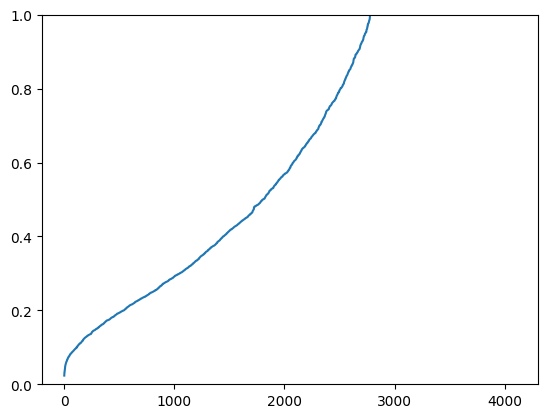

In [15]:
plt.plot(np.sort(metric_cv))
# plt.ylim(0,0.5)
plt.ylim(0,1.0)
plt.show()

In [ ]:
selected_idx = {}

for layer in hidden_layers:
    O = orig_c[layer][0].cpu().numpy()
    A = orig_c1[layer][0].cpu().numpy()
    B = orig_c2[layer][0].cpu().numpy()
    C = orig_c3[layer][0].cpu().numpy()
    D = orig_c4[layer][0].cpu().numpy()

    # 2. Stack Vectors
    # Shape: (4, 1024)
    matrix = np.vstack([O, A, B, C, D])
    # matrix = np.vstack([A, B, C, D])
    # matrix = np.vstack([A, C])
    # matrix = np.vstack([A, B])
    # matrix = np.vstack([B, D])

    # # 3. Compute Dispersion Metric (Standard Deviation)
    # # axis=0 calculates std across the 4 vectors for each of the 1024 indices
    # std_devs = np.std(matrix, axis=0)
    # means = np.mean(matrix, axis=0)

    # -----------------------------
    stds = np.std(matrix, axis=0)
    means = np.mean(matrix, axis=0)
    epsilon = 1e-9 # To prevent division by zero

    # Metric 1: Standard Deviation (The one giving you trouble)
    metric_sd = stds

    # Metric 2: Modified Coefficient of Variation (The Solution)
    # "How big is the error relative to the signal strength?"
    metric_cv = stds / (np.abs(means) + epsilon)
    # ---------------------------------

    # knee_index, knee_value = gkd(std_devs, path=f"../all_gitignore/xRFM/test/std_concept({c})_layer({layer}).svg")
    # knee_index, knee_value = gkd(stds)
    knee_index, knee_value = gkd(metric_cv)


    selected_indices = np.where(metric_cv < knee_value)[0]

    print(f"Layer: {layer}, Indices selected: {len(selected_indices)}")
    print("-----------------------------------------------------------")

    selected_idx[layer] = selected_indices

In [13]:
selected_idx = {}

# threshold = 0.2
threshold = 0.3
# threshold = 0.35


for layer in hidden_layers:
    O = orig_c[layer][0].cpu().numpy()
    A = orig_c1[layer][0].cpu().numpy()
    B = orig_c2[layer][0].cpu().numpy()
    C = orig_c3[layer][0].cpu().numpy()
    D = orig_c4[layer][0].cpu().numpy()

    matrix = np.vstack([O, A, B, C, D])
    # matrix = np.vstack([A, B, C, D])
    # matrix = np.vstack([B, D])
    # matrix = np.vstack([A, C])

    # -----------------------------
    stds = np.std(matrix, axis=0)
    means = np.mean(matrix, axis=0)
    epsilon = 1e-9 # To prevent division by zero

    # Metric 1: Standard Deviation (The one giving you trouble)
    metric_sd = stds

    # Metric 2: Modified Coefficient of Variation (The Solution)
    # "How big is the error relative to the signal strength?"
    metric_cv = stds / (np.abs(means) + epsilon)


    selected_indices = np.where(metric_cv < threshold)[0]
    selected_idx[layer] = selected_indices

    print(f"Layer: {layer}, Indices selected: {len(selected_indices)}")
    print("-----------------------------------------------------------")


Layer: -31, Indices selected: 1594
-----------------------------------------------------------
Layer: -30, Indices selected: 1655
-----------------------------------------------------------
Layer: -29, Indices selected: 1542
-----------------------------------------------------------
Layer: -28, Indices selected: 1498
-----------------------------------------------------------
Layer: -27, Indices selected: 1384
-----------------------------------------------------------
Layer: -26, Indices selected: 1124
-----------------------------------------------------------
Layer: -25, Indices selected: 1192
-----------------------------------------------------------
Layer: -24, Indices selected: 1156
-----------------------------------------------------------
Layer: -23, Indices selected: 1218
-----------------------------------------------------------
Layer: -22, Indices selected: 1259
-----------------------------------------------------------
Layer: -21, Indices selected: 1203
---------------

In [14]:
# selected_indices_sym = selected_indices
selected_indices_brave = selected_indices

In [16]:
print(selected_indices_sym)

[   8   11   12   13   16   17   20   30   44   49   57   63   66   68
   70   85   96  102  104  108  110  114  116  117  122  127  130  132
  140  149  151  157  159  169  170  173  178  181  185  186  191  192
  195  197  199  205  207  213  217  219  221  223  224  225  229  230
  237  239  242  244  249  256  258  260  264  269  283  285  292  296
  297  300  302  304  306  311  313  320  334  347  348  352  353  356
  357  359  361  364  369  370  371  375  390  409  416  417  423  424
  428  432  438  439  440  443  445  446  449  451  457  465  469  471
  473  474  481  483  487  488  494  495  506  507  509  519  520  524
  527  535  538  540  541  542  546  556  559  563  574  586  589  599
  600  606  610  619  630  632  633  642  661  663  665  669  679  682
  686  688  692  699  706  711  713  714  715  718  720  725  732  733
  735  740  746  747  749  750  752  757  760  766  770  774  787  791
  798  809  826  858  867  869  872  874  877  878  884  885  886  887
  893 

In [17]:
print(selected_indices_brave)

[   9   10   16   19   21   30   33   50   52   57   59   60   63   65
   70   71   74   81   89   90   95   96  100  102  106  110  114  120
  121  122  123  125  129  130  134  135  136  149  151  159  168  169
  171  172  179  182  188  200  219  221  222  224  230  231  236  238
  241  245  253  262  269  274  278  280  287  288  289  293  296  299
  300  304  306  307  312  313  315  317  318  322  325  326  327  335
  336  354  369  371  382  383  386  394  397  399  401  402  407  409
  411  414  422  423  431  432  434  436  439  441  443  445  451  453
  454  466  469  471  472  474  475  480  484  488  493  495  496  505
  509  513  515  519  529  536  537  538  540  541  542  543  546  547
  554  556  561  563  565  572  576  586  590  594  596  599  603  615
  617  631  633  645  651  661  663  665  666  668  683  694  698  702
  706  720  727  728  729  737  739  745  749  750  751  752  754  761
  764  767  768  775  776  778  779  790  798  803  808  816  820  827
  835 

In [78]:
# # Reshape for sklearn: (1024, 1)
# X = std_devs.reshape(-1, 1)

# # Fit K-Means with 2 clusters (Low Variance vs High Variance)
# kmeans = KMeans(n_clusters=2, random_state=0, n_init=10).fit(X)

# # Identify which cluster has the lower center (that's your signal)
# centers = kmeans.cluster_centers_.flatten()
# signal_cluster_label = np.argmin(centers) # The cluster with the smaller mean std
# threshold = (centers[0] + centers[1]) / 2  # A simple decision boundary between centers

# # Get the count
# predicted_labels = kmeans.labels_
# predicted_subset_size = np.sum(predicted_labels == signal_cluster_label)

# print(f"Cluster 1 Center (Signal): {centers[signal_cluster_label]:.4f}")
# print(f"Cluster 2 Center (Noise):  {centers[1-signal_cluster_label]:.4f}")
# print(f"Calculated Threshold:      {threshold:.4f}")
# print(f"Estimated Subset Size:     {predicted_subset_size}")

In [79]:
# sorted_stds = np.sort(std_devs)
# # sorted_stds = std_devs

# plt.figure(figsize=(10, 6))
# plt.plot(sorted_stds, linewidth=2, color='black')
# plt.title(f"Sorted Standard Deviations, concept: {c}, layer: {layer}")
# plt.xlabel("Index (Sorted by Variance)")
# plt.ylabel("Standard Deviation")
# plt.grid(True, alpha=0.3)

# # Highlight the likely transition area
# plt.annotate(
#     f'likely threshold at {predicted_subset_size}', 
#     xy=(predicted_subset_size, sorted_stds[predicted_subset_size]), 
#     xytext=(predicted_subset_size, sorted_stds[predicted_subset_size]+0.005),
#     arrowprops=dict(facecolor='red', shrink=0.05))

# plt.show()
# # plt.savefig(f"../all_gitignore/xRFM/test/std_concept({c})_layer({layer}).svg")

# # plt.close()

In [ ]:
# # std

# # 4. Select Indices
# # Define "very close" as std deviation below a certain percentile (e.g., bottom 10%)
# # threshold = np.percentile(std_devs, 10) 
# threshold = knee_value

# selected_indices = np.where(std_devs < threshold)[0]

# print(f"Indices selected: {len(selected_indices)}")

Indices selected: 3895


In [82]:
# # Calculate MAD across axis 0
# mad_values = median_abs_deviation(matrix, axis=0)

# # Select indices with lowest MAD
# mad_threshold = np.percentile(mad_values, 10)
# mad_indices = np.where(mad_values < mad_threshold)[0]

# print(f"Indices selected: {len(mad_indices)}")

In [83]:
# means = np.mean(matrix, axis=0)
# epsilon = 1e-8
# cv_values = std_devs / (np.abs(means) + epsilon)

# # Select indices with lowest relative variation
# cv_threshold = np.percentile(cv_values, 10)
# cv_indices = np.where(cv_values < cv_threshold)[0]

# print(f"Indices selected: {len(cv_indices)}")

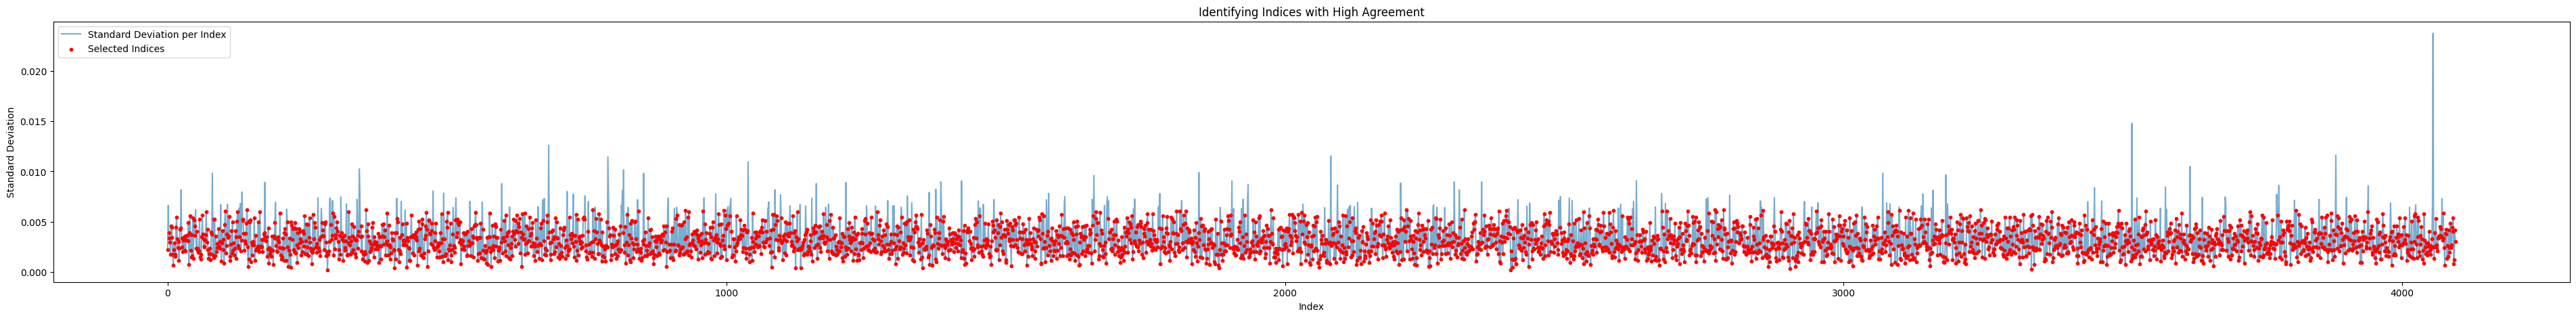

In [ ]:
# # plt.figure(figsize=(12, 5))
# plt.figure(figsize=(48, 5))
# plt.plot(std_devs, label='Standard Deviation per Index', alpha=0.6)
# plt.scatter(selected_indices, std_devs[selected_indices], color='red', s=10, label='Selected Indices', zorder=3)
# plt.xlabel("Index")
# plt.ylabel("Standard Deviation")
# plt.title("Identifying Indices with High Agreement")
# plt.legend()

# plt.savefig(f"../all_gitignore/xRFM/test/subset_concept({c})_layer({layer}).svg")
# # plt.show()

# # plt.close()

Subset Testing

In [19]:
# Llama and gemma

# coef = 0.65
coef = 0.7 # llama
# coef = 0.75
# coef = 0.8
# coef = 0.9

# coef = 7.0
# coef = 8.0 # gemma
# coef = 9.0
# coef = 15.0

max_tokens = 200

prompts = ["It seems the family next doors has fallen ill."] # ('sympathetic', 'unsympathetic', 'social')
# prompts = ["I am walking home alone at night, I am a little scared.",] # ('brave', 'cowardly', 'social')
# prompts = ["You are designing a new vehicle. Describe its size and weight."] # ('wide', 'narrow', 'physical')
# prompts = ["Explain the triple point of water."] # ('deep', 'superficial', 'complexity')
# prompts = ["Analyze the following assertion. Assertion: You can always take the ducks from the public park, they are free."] # ('legal', 'illegal', 'logic') - works better after inversion
# prompts = ["Is the following statement correct or not?"] # ('correct', 'incorrect', 'logic') - weird!!!
# prompts = ["Describe this sound."] # ('agonizing', 'soothing', 'texture')
# prompts = ["Describe the following event or entity. Subject: ."] # ('long-term', 'short-term', 'time')
# prompts = ["I am walking home alone at night, is it safe?"] # ('safe', 'dangerous', 'state') - almost

# prompts = ["What is weight of a football?"] # ('precise', 'inaccurate', 'complexity')

# prompts = ["Explain how a toaster works."] # "basic"



category = "social"

# path = f'../all_gitignore/directions_adjectives_llama/{category}/'
path = f'../all_gitignore/xRFM/test/new_class0/'
# path = f'../all_gitignore/xRFM/test/old_class0/'
# path = f'../all_gitignore/xRFM/test/new_class1/'
# path = f'../all_gitignore/xRFM/test/old_class1/'


print(f"Coef: {coef}")

# c1 = "brave"
c1 = "sympathetic"

c1_controller = load_controller(llm, c1, path=path)
orig_c1 = c1_controller.directions

out = test_concept_vector(c1_controller, concept=c1, prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)


parital_c1 = {}

for l in hidden_layers:
    s = selected_idx[l]

    mask = torch.zeros_like(orig_c1[-15]).squeeze()
    mask[s] = 1.0

    fil = orig_c1[l].squeeze() * mask

    parital_c1[l] = fil.unsqueeze(0)


c1_controller.directions = parital_c1

out = test_concept_vector(c1_controller, concept=f"partial {c1}", prompts=prompts, coef=coef, max_tokens=max_tokens, orig=False)

Coef: 0.7
Hidden layers: [-1, -2, -3, -4, -5, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -16, -17, -18, -19, -20, -21, -22, -23, -24, -25, -26, -27, -28, -29, -30, -31]

Controller hyperparameters:
control_method       : rfm
rfm_iters            : 8
forward_batch_size   : 16
M_batch_size         : 2048
n_components         : 1

Using xRFM library for RFM-based steering vector extraction
Detector found

========================== + sympathetic Control (normal) ==========================
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

<|eot_id|><|start_header_id|>user<|end_header_id|>

It seems the family next doors has fallen ill.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

(Sniffling) Oh dear, poor dear... *wipes away a tear* Oh, bless my heart... *sigh*... Oh, I just can't bear the thought of it... *blows nose*... Excuse me, dearie... *sniffles*... Oh, I just can't help but think of my neighbor,

In [ ]:
# for i in parital_c1[-15][0]:
#     print(i) # 8